# Corrected Macroeconomic Data Processing

This notebook rebuilds the macroeconomic modelling dataset using a consistent common observation calendar.

The raw level series are aligned before transformations are applied. This ensures that log returns and first differences are calculated between consecutive observations retained in the final modelling dataset, allowing forecasts to be reconstructed correctly into original levels.

Transformations:

- EUR/USD (`DEXUSEU`): log returns
- US 2-year Treasury yield (`DGS2`): first differences
- US Economic Policy Uncertainty (`USEPUINDXD`): first differences
- VIX (`VIXCLS`): retained in levels because it is stationary

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller

In [2]:
# Input files: original raw FRED data

DEXUSEU_PATH = Path(
    r"C:\Users\franc\OneDrive\Geop-Model\data\raw\DEXUSEU.csv"
)

DGS2_PATH = Path(
    r"C:\Users\franc\OneDrive\Geop-Model\data\raw\DGS2.csv"
)

USEPU_PATH = Path(
    r"C:\Users\franc\OneDrive\Geop-Model\data\raw\USEPUINDXD.csv"
)

VIX_PATH = Path(
    r"C:\Users\franc\OneDrive\Geop-Model\data\raw\VIXCLS.csv"
)


# Output files: new corrected repository

PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)

LEVELS_OUTPUT_PATH = (
    PROCESSED_DIR
    / "macro_levels_aligned.csv"
)

PROCESSED_OUTPUT_PATH = (
    PROCESSED_DIR
    / "macro_processed.csv"
)


input_paths = {
    "DEXUSEU": DEXUSEU_PATH,
    "DGS2": DGS2_PATH,
    "USEPUINDXD": USEPU_PATH,
    "VIXCLS": VIX_PATH
}

for name, path in input_paths.items():
    print(f"{name}: {path.exists()} — {path}")

print("\nOutputs will be saved to:")
print(LEVELS_OUTPUT_PATH)
print(PROCESSED_OUTPUT_PATH)

DEXUSEU: True — C:\Users\franc\OneDrive\Geop-Model\data\raw\DEXUSEU.csv
DGS2: True — C:\Users\franc\OneDrive\Geop-Model\data\raw\DGS2.csv
USEPUINDXD: True — C:\Users\franc\OneDrive\Geop-Model\data\raw\USEPUINDXD.csv
VIXCLS: True — C:\Users\franc\OneDrive\Geop-Model\data\raw\VIXCLS.csv

Outputs will be saved to:
c:\Users\franc\OneDrive\Geop-Model\Geop-Model-main\data\processed\macro_levels_aligned.csv
c:\Users\franc\OneDrive\Geop-Model\Geop-Model-main\data\processed\macro_processed.csv


In [3]:
def load_fred_series(path, value_column):
    """
    Load one raw FRED CSV.

    Returns a dataframe indexed by observation_date containing
    one numeric value column.
    """
    data = pd.read_csv(path)

    if "observation_date" not in data.columns:
        raise KeyError(
            f"'observation_date' was not found in {path.name}. "
            f"Columns found: {data.columns.tolist()}"
        )

    if value_column not in data.columns:
        raise KeyError(
            f"'{value_column}' was not found in {path.name}. "
            f"Columns found: {data.columns.tolist()}"
        )

    data["observation_date"] = pd.to_datetime(
        data["observation_date"],
        errors="coerce"
    )

    data[value_column] = pd.to_numeric(
        data[value_column],
        errors="coerce"
    )

    data = (
        data[
            ["observation_date", value_column]
        ]
        .dropna(subset=["observation_date"])
        .drop_duplicates(
            subset="observation_date",
            keep="last"
        )
        .set_index("observation_date")
        .sort_index()
    )

    return data

## 1. Load Raw Macroeconomic Series

The four raw FRED series are loaded separately and converted into consistently indexed numeric time series.

The raw variables are:

- EUR/USD spot (`DEXUSEU`)
- US 2-Year Treasury yield (`DGS2`)
- US Economic Policy Uncertainty Index (`USEPUINDXD`)
- VIX (`VIXCLS`)

Each series is sorted chronologically and checked for valid observation dates before the common modelling calendar is constructed.

In [4]:
eurusd_raw = load_fred_series(
    DEXUSEU_PATH,
    "DEXUSEU"
)

dgs2_raw = load_fred_series(
    DGS2_PATH,
    "DGS2"
)

usepu_raw = load_fred_series(
    USEPU_PATH,
    "USEPUINDXD"
)

vix_raw = load_fred_series(
    VIX_PATH,
    "VIXCLS"
)


print("EUR/USD:", eurusd_raw.shape)
print("DGS2:", dgs2_raw.shape)
print("USEPU:", usepu_raw.shape)
print("VIX:", vix_raw.shape)

display(eurusd_raw.head())
display(dgs2_raw.head())
display(usepu_raw.head())
display(vix_raw.head())

EUR/USD: (2494, 1)
DGS2: (2494, 1)
USEPU: (3495, 1)
VIX: (2495, 1)


,DEXUSEU
observation_date,
2017-01-03,1.0416
2017-01-04,1.0476
2017-01-05,1.0598
2017-01-06,1.0560
2017-01-09,1.0576


,DGS2
observation_date,
2017-01-03,1.22
2017-01-04,1.24
2017-01-05,1.17
2017-01-06,1.22
2017-01-09,1.21


,USEPUINDXD
observation_date,
2017-01-01,235.10
2017-01-02,242.04
2017-01-03,89.85
2017-01-04,101.99
2017-01-05,134.47


,VIXCLS
observation_date,
2017-01-03,12.85
2017-01-04,11.85
2017-01-05,11.67
2017-01-06,11.32
2017-01-09,11.56


## 2. Construction of the Common Observation Calendar

The raw level series are first combined using an outer join so that missing observations across the individual data sources can be identified explicitly.

Only dates for which all four macroeconomic variables are available are subsequently retained. This creates a common observation calendar before any transformations are calculated.

Aligning the raw levels first ensures that first differences and log returns correspond to consecutive observations in the final modelling sample.

In [5]:
macro_raw_outer = (
    eurusd_raw
    .join(dgs2_raw, how="outer")
    .join(usepu_raw, how="outer")
    .join(vix_raw, how="outer")
    .sort_index()
)

print("Outer-merged raw shape:", macro_raw_outer.shape)

print("\nMissing values before selecting common observations:")
print(macro_raw_outer.isna().sum())

display(macro_raw_outer.head(10))

Outer-merged raw shape: (3495, 4)

Missing values before selecting common observations:
DEXUSEU       1108
DGS2          1105
USEPUINDXD       0
VIXCLS        1060
dtype: int64


,DEXUSEU,DGS2,USEPUINDXD,VIXCLS
observation_date,,,,
2017-01-01,NaN,NaN,235.10,NaN
2017-01-02,NaN,NaN,242.04,NaN
2017-01-03,1.0416,1.22,89.85,12.85
2017-01-04,1.0476,1.24,101.99,11.85
2017-01-05,1.0598,1.17,134.47,11.67
2017-01-06,1.0560,1.22,96.97,11.32
2017-01-07,NaN,NaN,110.23,NaN
2017-01-08,NaN,NaN,272.01,NaN
2017-01-09,1.0576,1.21,121.76,11.56


In [6]:
# Retain only dates for which all four raw level variables exist

macro_levels = (
    macro_raw_outer
    .dropna(
        subset=[
            "DEXUSEU",
            "DGS2",
            "USEPUINDXD",
            "VIXCLS"
        ]
    )
    .copy()
)

print("Complete aligned level sample:", macro_levels.shape)
print(
    "Sample period:",
    macro_levels.index.min(),
    "to",
    macro_levels.index.max()
)

print("\nRemaining missing values:")
print(macro_levels.isna().sum())

display(macro_levels.head())

Complete aligned level sample: (2377, 4)
Sample period: 2017-01-03 00:00:00 to 2026-07-24 00:00:00

Remaining missing values:
DEXUSEU       0
DGS2          0
USEPUINDXD    0
VIXCLS        0
dtype: int64


,DEXUSEU,DGS2,USEPUINDXD,VIXCLS
observation_date,,,,
2017-01-03,1.0416,1.22,89.85,12.85
2017-01-04,1.0476,1.24,101.99,11.85
2017-01-05,1.0598,1.17,134.47,11.67
2017-01-06,1.0560,1.22,96.97,11.32
2017-01-09,1.0576,1.21,121.76,11.56


In [7]:
assert macro_levels.index.is_monotonic_increasing
assert macro_levels.index.is_unique
assert not macro_levels.isna().any().any()

date_gaps = (
    macro_levels.index
    .to_series()
    .diff()
    .value_counts()
    .sort_index()
)

print("Most common gaps between retained observations:")
display(date_gaps.head(10))

Most common gaps between retained observations:


observation_date
1 days    1850
2 days      28
3 days     412
4 days      83
5 days       3
Name: count, dtype: int64

## 3. Variable Transformations

The aligned macroeconomic level series are transformed into the stationary representations used by the VAR-X models.

The transformations are:

- EUR/USD spot: log returns
- US 2-Year Treasury yield: first differences
- US Economic Policy Uncertainty: first differences
- VIX: retained in levels

Because log returns and first differences require a preceding observation, the first aligned date is removed from the transformed dataset.

The corresponding level dataset is then restricted to the exact same dates as the processed modelling sample.

In [8]:
macro_processed = pd.DataFrame(
    index=macro_levels.index
)

# EUR/USD: log return
macro_processed["DEXUSEU_logreturn"] = (
    np.log(macro_levels["DEXUSEU"])
    .diff()
)

# US 2-year yield: first difference
macro_processed["DGS2_diff"] = (
    macro_levels["DGS2"]
    .diff()
)

# Economic Policy Uncertainty: first difference
macro_processed["USEPUINDXD_diff"] = (
    macro_levels["USEPUINDXD"]
    .diff()
)

# VIX: stationary in levels
macro_processed["VIXCLS"] = (
    macro_levels["VIXCLS"]
)

# The first row is missing because of differencing/log returns
macro_processed = macro_processed.dropna().copy()

# Keep the corresponding aligned levels on exactly the same dates
macro_levels_model = macro_levels.loc[
    macro_processed.index
].copy()

print("Processed shape:", macro_processed.shape)
print("Aligned level shape:", macro_levels_model.shape)

print("\nMissing transformed values:")
print(macro_processed.isna().sum())

display(macro_processed.head())

Processed shape: (2376, 4)
Aligned level shape: (2376, 4)

Missing transformed values:
DEXUSEU_logreturn    0
DGS2_diff            0
USEPUINDXD_diff      0
VIXCLS               0
dtype: int64


,DEXUSEU_logreturn,DGS2_diff,USEPUINDXD_diff,VIXCLS
observation_date,,,,
2017-01-04,0.005744,0.02,12.14,11.85
2017-01-05,0.011578,-0.07,32.48,11.67
2017-01-06,-0.003592,0.05,-37.50,11.32
2017-01-09,0.001514,-0.01,24.79,11.56
2017-01-10,-0.000378,-0.02,0.14,11.49


In [9]:
def adf_test(series, significance=0.05):
    clean = series.dropna()

    result = adfuller(
        clean,
        autolag="AIC"
    )

    return {
        "adf_stat": result[0],
        "pvalue": result[1],
        "n_lags": result[2],
        "n_obs": result[3],
        "stationary": result[1] < significance
    }

## 4. Stationarity Validation

Augmented Dickey-Fuller tests are applied to each transformed macroeconomic series to confirm that the representations used in the VAR-X models are stationary.

The tests provide a final validation of the transformation choices before the processed dataset is exported for modelling.

In [10]:
adf_results = pd.DataFrame(
    {
        column: adf_test(
            macro_processed[column]
        )
        for column in macro_processed.columns
    }
).T

display(
    adf_results[
        [
            "adf_stat",
            "pvalue",
            "n_lags",
            "n_obs",
            "stationary"
        ]
    ].round(4)
)

,adf_stat,pvalue,n_lags,n_obs,stationary
DEXUSEU_logreturn,-21.41433,0.0,5,2370,True
DGS2_diff,-9.939034,0.0,17,2358,True
USEPUINDXD_diff,-12.182284,0.0,23,2352,True
VIXCLS,-5.221725,0.000008,9,2366,True


## 5. Transformation Reconstruction Check

The transformed series are reconstructed back into their original levels to verify that the preprocessing procedure is internally consistent.

EUR/USD levels are recovered by cumulatively applying the log returns to the preceding observed spot rate. The US 2-Year Treasury yield and Economic Policy Uncertainty levels are reconstructed by cumulatively adding their first differences.

The reconstructed series are compared with the original aligned level observations. Exact agreement, up to numerical floating-point tolerance, confirms that the transformed series can later be converted back into economically interpretable levels during forecast evaluation.

In [11]:
# Exact reconstruction validation over the complete processed sample

reconstructed = pd.DataFrame(
    index=macro_processed.index
)

# Starting levels are the raw aligned levels immediately before
# the first transformed observation
first_processed_date = macro_processed.index[0]

first_position = macro_levels.index.get_loc(
    first_processed_date
)

if first_position == 0:
    raise ValueError(
        "No preceding level observation is available for reconstruction."
    )

starting_date = macro_levels.index[
    first_position - 1
]

start_eurusd = macro_levels.loc[
    starting_date,
    "DEXUSEU"
]

start_dgs2 = macro_levels.loc[
    starting_date,
    "DGS2"
]

start_usepu = macro_levels.loc[
    starting_date,
    "USEPUINDXD"
]


# Log return -> EUR/USD level
reconstructed["DEXUSEU"] = (
    start_eurusd
    * np.exp(
        macro_processed[
            "DEXUSEU_logreturn"
        ].cumsum()
    )
)

# First difference -> DGS2 level
reconstructed["DGS2"] = (
    start_dgs2
    + macro_processed[
        "DGS2_diff"
    ].cumsum()
)

# First difference -> USEPU level
reconstructed["USEPUINDXD"] = (
    start_usepu
    + macro_processed[
        "USEPUINDXD_diff"
    ].cumsum()
)

# VIX was never transformed
reconstructed["VIXCLS"] = (
    macro_processed["VIXCLS"]
)


actual_levels = macro_levels_model[
    [
        "DEXUSEU",
        "DGS2",
        "USEPUINDXD",
        "VIXCLS"
    ]
]

reconstruction_error = (
    reconstructed
    - actual_levels
)

max_reconstruction_error = (
    reconstruction_error
    .abs()
    .max()
)

print("Maximum reconstruction error:")
print(max_reconstruction_error)

Maximum reconstruction error:
DEXUSEU       2.220446e-16
DGS2          4.440892e-16
USEPUINDXD    3.979039e-13
VIXCLS        0.000000e+00
dtype: float64


In [12]:
TOLERANCE = 1e-9

if not (
    max_reconstruction_error
    < TOLERANCE
).all():
    raise AssertionError(
        "Reconstruction validation failed.\n"
        f"{max_reconstruction_error}"
    )

print(
    "Round-trip reconstruction passed "
    f"with tolerance {TOLERANCE}."
)

Round-trip reconstruction passed with tolerance 1e-09.


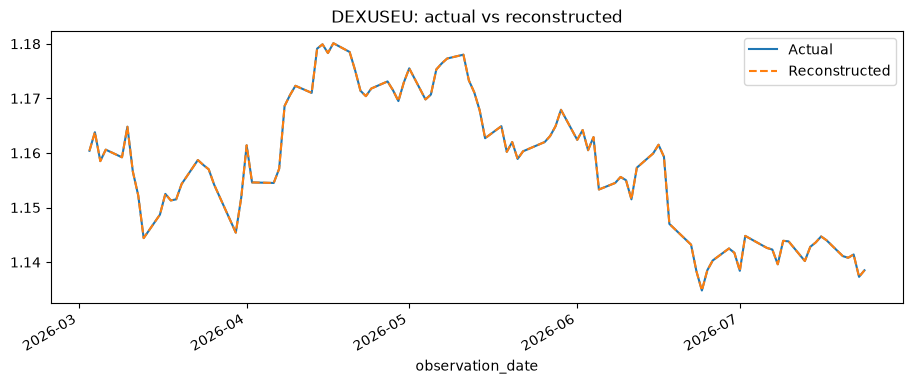

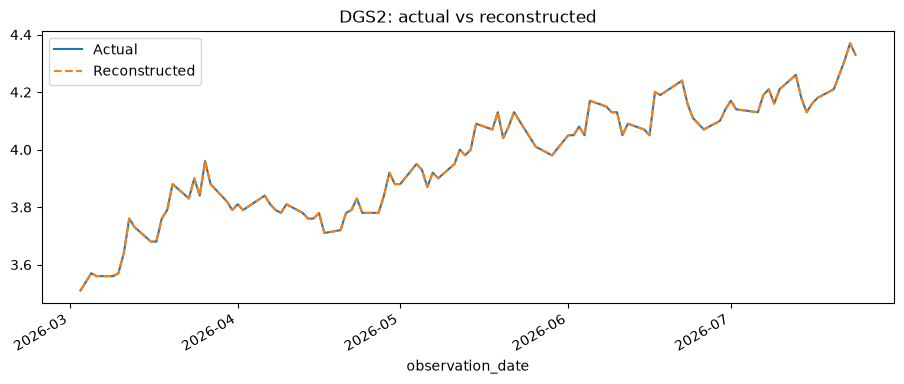

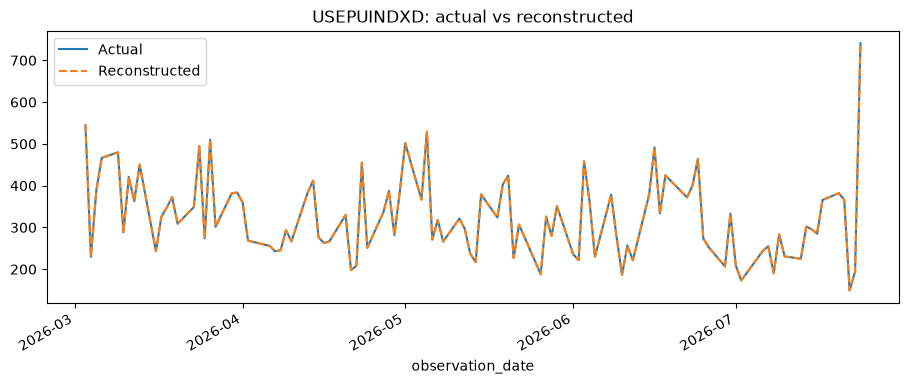

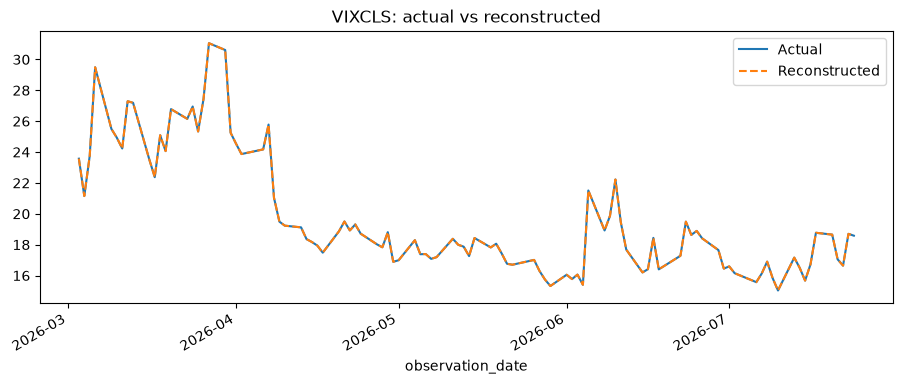

In [13]:
for column in actual_levels.columns:
    ax = actual_levels[column].tail(100).plot(
        figsize=(11, 4),
        label="Actual",
        title=f"{column}: actual vs reconstructed"
    )

    reconstructed[column].tail(100).plot(
        ax=ax,
        linestyle="--",
        label="Reconstructed"
    )

    ax.legend()
    plt.show()

## 6. Export of Processed Macroeconomic Data

Two datasets are exported for subsequent modelling:

- `macro_levels_aligned.csv`, containing the aligned macroeconomic variables in their original levels;
- `macro_processed.csv`, containing the stationary transformations used by the VAR-X models.

Both datasets use the same observation dates, allowing transformed forecasts to be reconstructed consistently into original levels where required.

In [14]:
PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

levels_to_save = (
    macro_levels_model
    .reset_index()
)

processed_to_save = (
    macro_processed
    .reset_index()
)

levels_to_save.to_csv(
    LEVELS_OUTPUT_PATH,
    index=False
)

processed_to_save.to_csv(
    PROCESSED_OUTPUT_PATH,
    index=False
)

print("Saved aligned levels:")
print(LEVELS_OUTPUT_PATH)

print("\nSaved corrected transformed data:")
print(PROCESSED_OUTPUT_PATH)

print("\nShapes:")
print("Levels:", levels_to_save.shape)
print("Processed:", processed_to_save.shape)

Saved aligned levels:
c:\Users\franc\OneDrive\Geop-Model\Geop-Model-main\data\processed\macro_levels_aligned.csv

Saved corrected transformed data:
c:\Users\franc\OneDrive\Geop-Model\Geop-Model-main\data\processed\macro_processed.csv

Shapes:
Levels: (2376, 5)
Processed: (2376, 5)


In [15]:
levels_check = pd.read_csv(
    LEVELS_OUTPUT_PATH
)

processed_check = pd.read_csv(
    PROCESSED_OUTPUT_PATH
)

print("Saved levels shape:", levels_check.shape)
print("Saved processed shape:", processed_check.shape)

print("\nProcessed columns:")
print(processed_check.columns.tolist())

display(processed_check.head())

Saved levels shape: (2376, 5)
Saved processed shape: (2376, 5)

Processed columns:
['observation_date', 'DEXUSEU_logreturn', 'DGS2_diff', 'USEPUINDXD_diff', 'VIXCLS']


,observation_date,DEXUSEU_logreturn,DGS2_diff,USEPUINDXD_diff,VIXCLS
0,2017-01-04,0.005744,0.02,12.14,11.85
1,2017-01-05,0.011578,-0.07,32.48,11.67
2,2017-01-06,-0.003592,0.05,-37.50,11.32
3,2017-01-09,0.001514,-0.01,24.79,11.56
4,2017-01-10,-0.000378,-0.02,0.14,11.49


## 7. Summary

This notebook rebuilds the macroeconomic modelling dataset using a common observation calendar established before any transformations are applied.

EUR/USD is represented using log returns, the US 2-Year Treasury yield and Economic Policy Uncertainty Index are first-differenced, and VIX is retained in levels. Augmented Dickey-Fuller tests are used to verify stationarity of the resulting modelling variables.

A round-trip reconstruction check confirms that the transformed EUR/USD, Treasury-yield and Economic Policy Uncertainty series reproduce the corresponding original level observations to numerical precision.

The final aligned-level and transformed datasets are exported as `macro_levels_aligned.csv` and `macro_processed.csv` for use throughout the subsequent VAR-X and forecasting analysis.